In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [7]:
import pickle

with open("Corr_len_cytnx.pkl", "rb") as file:
    loaded_data = pickle.load(file)
    
Corr_len_cytnx = loaded_data['Corr_len']
Corr_len_2_cytnx = loaded_data['Corr_len_2']
Corr_len_4_cytnx = loaded_data['Corr_len_4']
Corr_len_10_cytnx = loaded_data['Corr_len_10']
Corr_len_20_cytnx = loaded_data['Corr_len_20']

In [8]:
def get_W(beta, J=1, h=0):
    """
    Calculate the matrix W based on beta, J, and h.
    
    Parameters:
        beta (float): Inverse temperature.
        J (float): Interaction strength (default is 1).
        h (float): External field strength (default is 0).

    Returns:
        torch.Tensor: Matrix W.
    """
    sq_cosh = np.sqrt(np.cosh(beta * J))
    sq_sinh = np.sqrt(np.sinh(beta * J))
    W = torch.tensor([
        [sq_cosh, sq_sinh],
        [sq_cosh, -sq_sinh]
    ])
    return W


#可能Wh是正確的包含h的作法
def get_Wh(beta, J, h):
    """
    Calculate the matrix Wh incorporating the external field h.
    
    Parameters:
        beta (float): Inverse temperature.
        J (float): Interaction strength.
        h (float): External field strength.

    Returns:
        torch.Tensor: Matrix Wh.
    """
    cosh = np.cosh(beta * J)
    sinh = np.sinh(beta * J)

    Wh = torch.tensor([
        [np.sqrt(cosh) * np.exp(beta * h / 2), np.sqrt(sinh) * np.exp(beta * h / 2)],
        [np.sqrt(cosh) * np.exp(-beta * h / 2), -np.sqrt(sinh) * np.exp(-beta * h / 2)]
    ])
    return Wh


# 上左右下
def get_T_bare(beta, J=1, h=0, get_W=get_W):
    """
    Calculate the bare transfer matrix T_bare.
    
    Parameters:
        beta (float): Inverse temperature.
        J (float): Interaction strength (default is 1).
        h (float): External field strength (default is 0).
        get_W (callable): Function to calculate W or Wh (default is get_W).

    Returns:
        torch.Tensor: Bare transfer matrix T_bare.
    """
    W = get_W(beta, J=J, h=h)
    T_bare = torch.einsum('ai,aj,ak,al->ijkl', W, W, W, W)
    return T_bare

def merge_y(Tup, Tdn, combine=False, trace=False):
    if trace:
        Tmerge = torch.einsum('abcd,defa->becf', Tup, Tdn)
        
        if combine:
            shape = Tmerge.shape
            Tmerge = Tmerge.contiguous().view(shape[0] * shape[1], shape[2] * shape[3])
    else:
        Tmerge = torch.einsum('abcd,defg->abecfg', Tup, Tdn)
        
        if combine:
            shape = Tmerge.shape
            Tmerge = Tmerge.contiguous().view(shape[0], shape[1] * shape[2], shape[3] * shape[4], shape[5])
            
    return Tmerge


def merge_y_truncate(Tup, Tdn, dcut):
    if ((Tup.shape[1] * Tdn.shape[1]) < dcut):
        return merge_y(Tup, Tdn, True)
    Tmerge_pure = torch.einsum('aAbc,cBef,aCbd,dDef->ABCD', Tup, Tdn, Tup, Tdn)
    Tmerge_pure_shape = Tmerge_pure.shape
    Tmerge_pure = Tmerge_pure.contiguous().view(
        Tmerge_pure_shape[0] * Tmerge_pure_shape[1],Tmerge_pure_shape[2] * Tmerge_pure_shape[3]
    )
    U, S, V = torch.svd(Tmerge_pure)
    U = U[:,:dcut]
    U = U.view(Tmerge_pure_shape[0], Tmerge_pure_shape[1], dcut)
    Tmerge = torch.einsum('Aace,ebdD,cdC,abB->ABCD', Tup, Tdn, U, U)
    return Tmerge

def merge_x(TL, TR, combine=False, trace=False):
    if trace:
        Tmerge = torch.einsum('aAca,ecBe->AB', TL, TR)
    else:
        Tmerge = torch.einsum('BCaF,AaDE->ABCDEF', TL, TR)
        
        if combine:
            shape = Tmerge.shape
            Tmerge = Tmerge.contiguous().view(shape[0] * shape[1], shape[2], shape[3], shape[4] * shape[5])
            
    return Tmerge

def merge_x_truncate(TL, TR, dcut):
    if ((TL.shape[0] * TR.shape[0]) < dcut):
        return merge_x(TL, TR, True)
    Tmerge_pure = torch.einsum('abcd,ecfg,hbid,jifg->aehj', TL, TR, TL, TR)
    Tmerge_pure_shape = Tmerge_pure.shape
    Tmerge_pure = Tmerge_pure.contiguous().view(
        Tmerge_pure_shape[0] * Tmerge_pure_shape[1],Tmerge_pure_shape[2] * Tmerge_pure_shape[3]
    )
    U, S, V = torch.svd(Tmerge_pure)
    U = U[:,:dcut]
    U = U.view(Tmerge_pure_shape[0], Tmerge_pure_shape[1], dcut)
    Tmerge = torch.einsum('abcd,ecfg,aeh,dgi->hbfi', TL, TR, U, U)
    return Tmerge

In [4]:
MaxL = 4
Temp = np.linspace(2.26,4,100)
W = np.ones((MaxL+1,len(Temp),2))
E = np.ones((MaxL+1,len(Temp),2))
Tc = 2/np.log(1+np.sqrt(2))

In [5]:
%%time

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TL_Trace = merge_y(TL,TL,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        del TL_Trace
        if j != MaxL:
            TL = merge_y(TL,TL,True)
E = -np.log(W)
Corr_len = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len, Corr_len_cytnx)

CPU times: user 2.26 s, sys: 1.74 s, total: 4 s
Wall time: 716 ms


<timed exec>:12: RuntimeWarning: divide by zero encountered in divide


True

In [6]:
%%time
dcut = 2

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_2 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_2, Corr_len_2_cytnx)

CPU times: user 254 ms, sys: 0 ns, total: 254 ms
Wall time: 261 ms


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


True

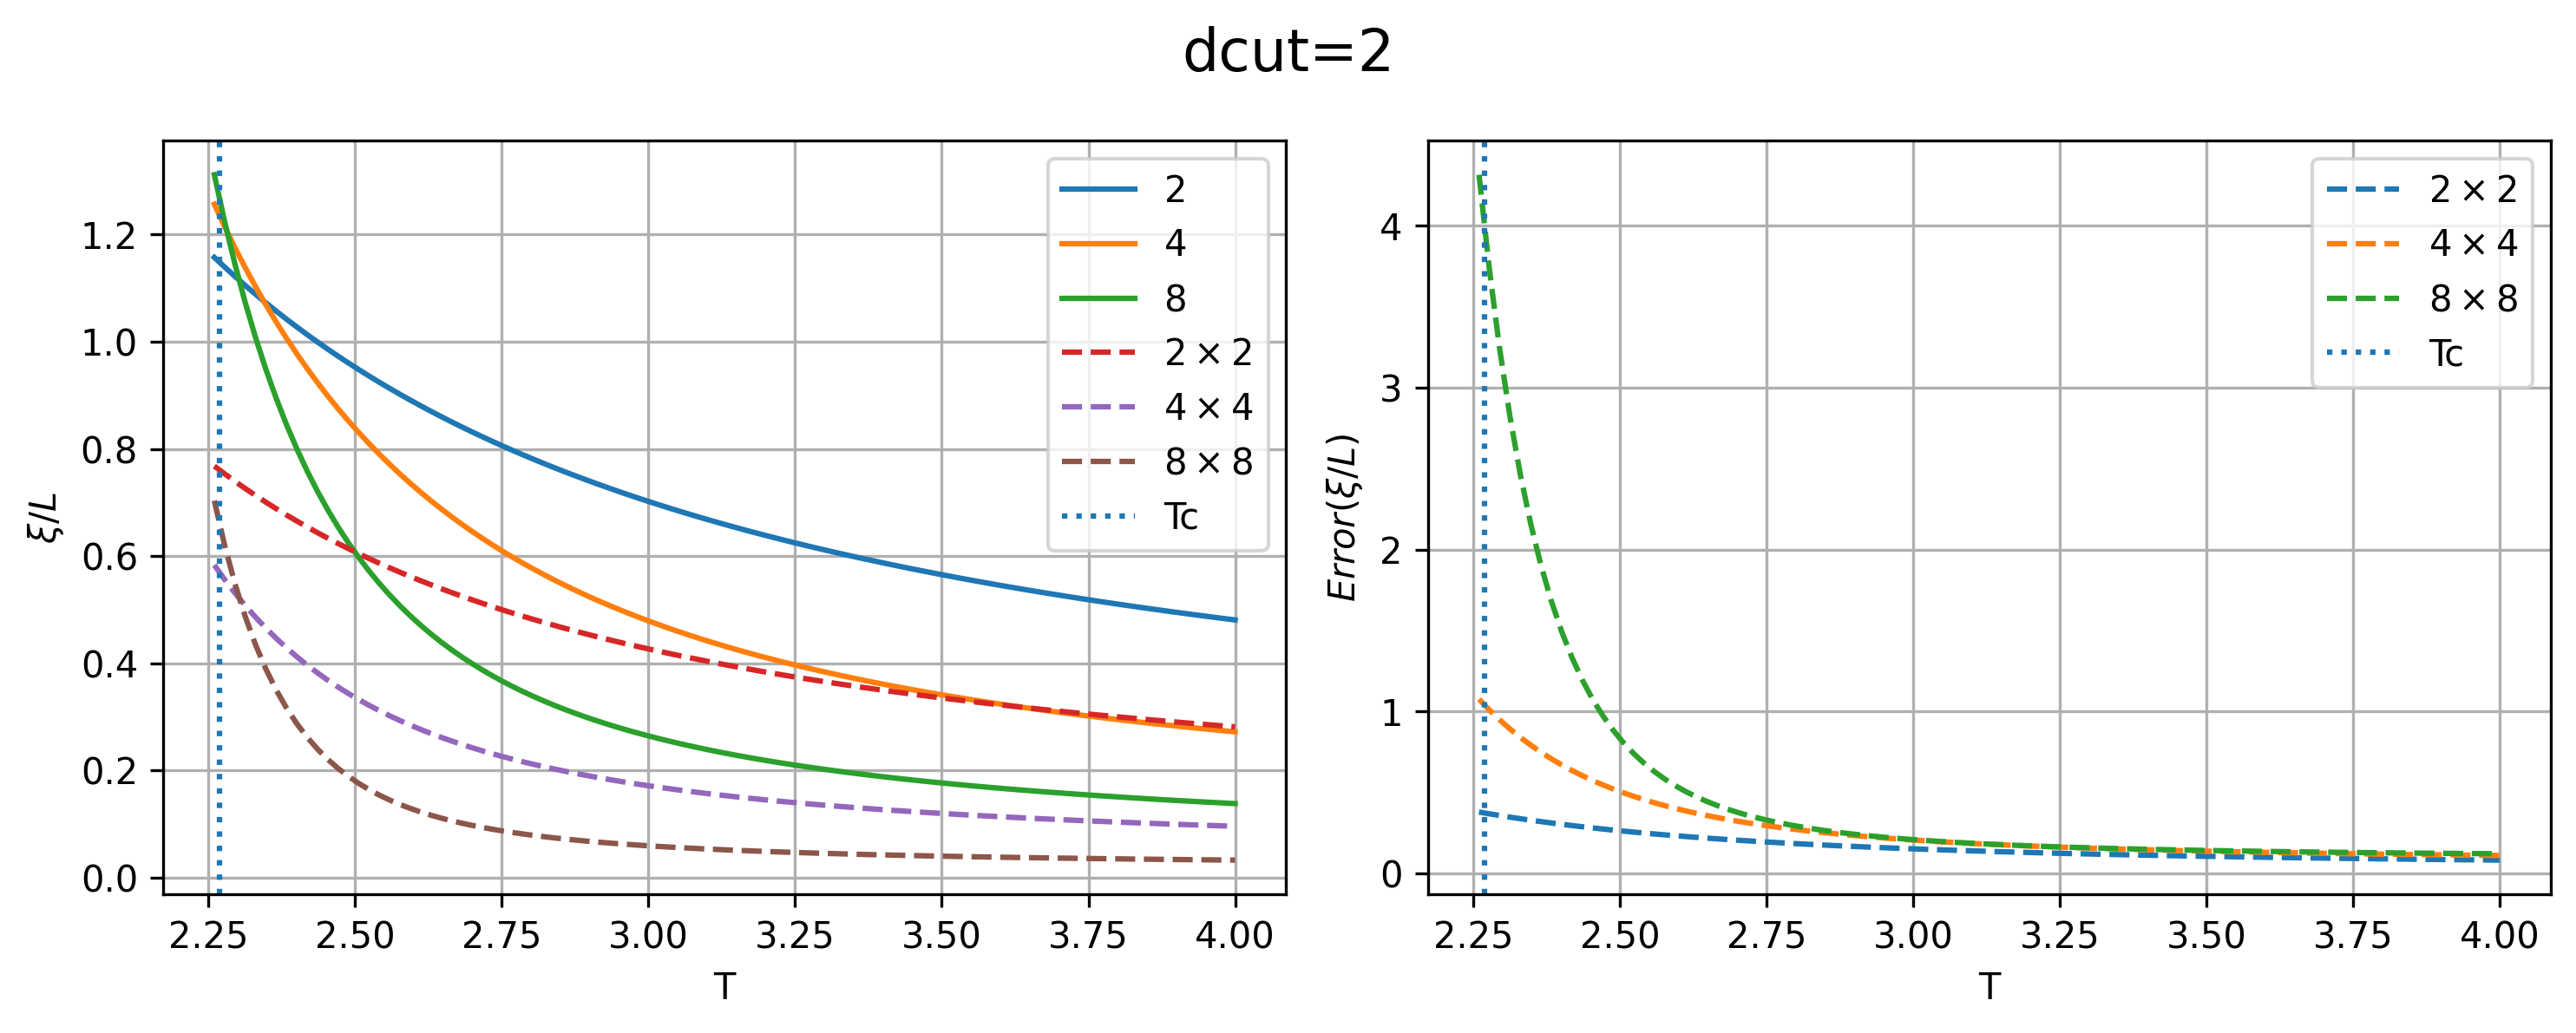

In [8]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_2[i]/2**(i-1),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_2[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
%%time
dcut = 4

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_4 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_4, Corr_len_4_cytnx)

CPU times: user 274 ms, sys: 0 ns, total: 274 ms
Wall time: 275 ms


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


True

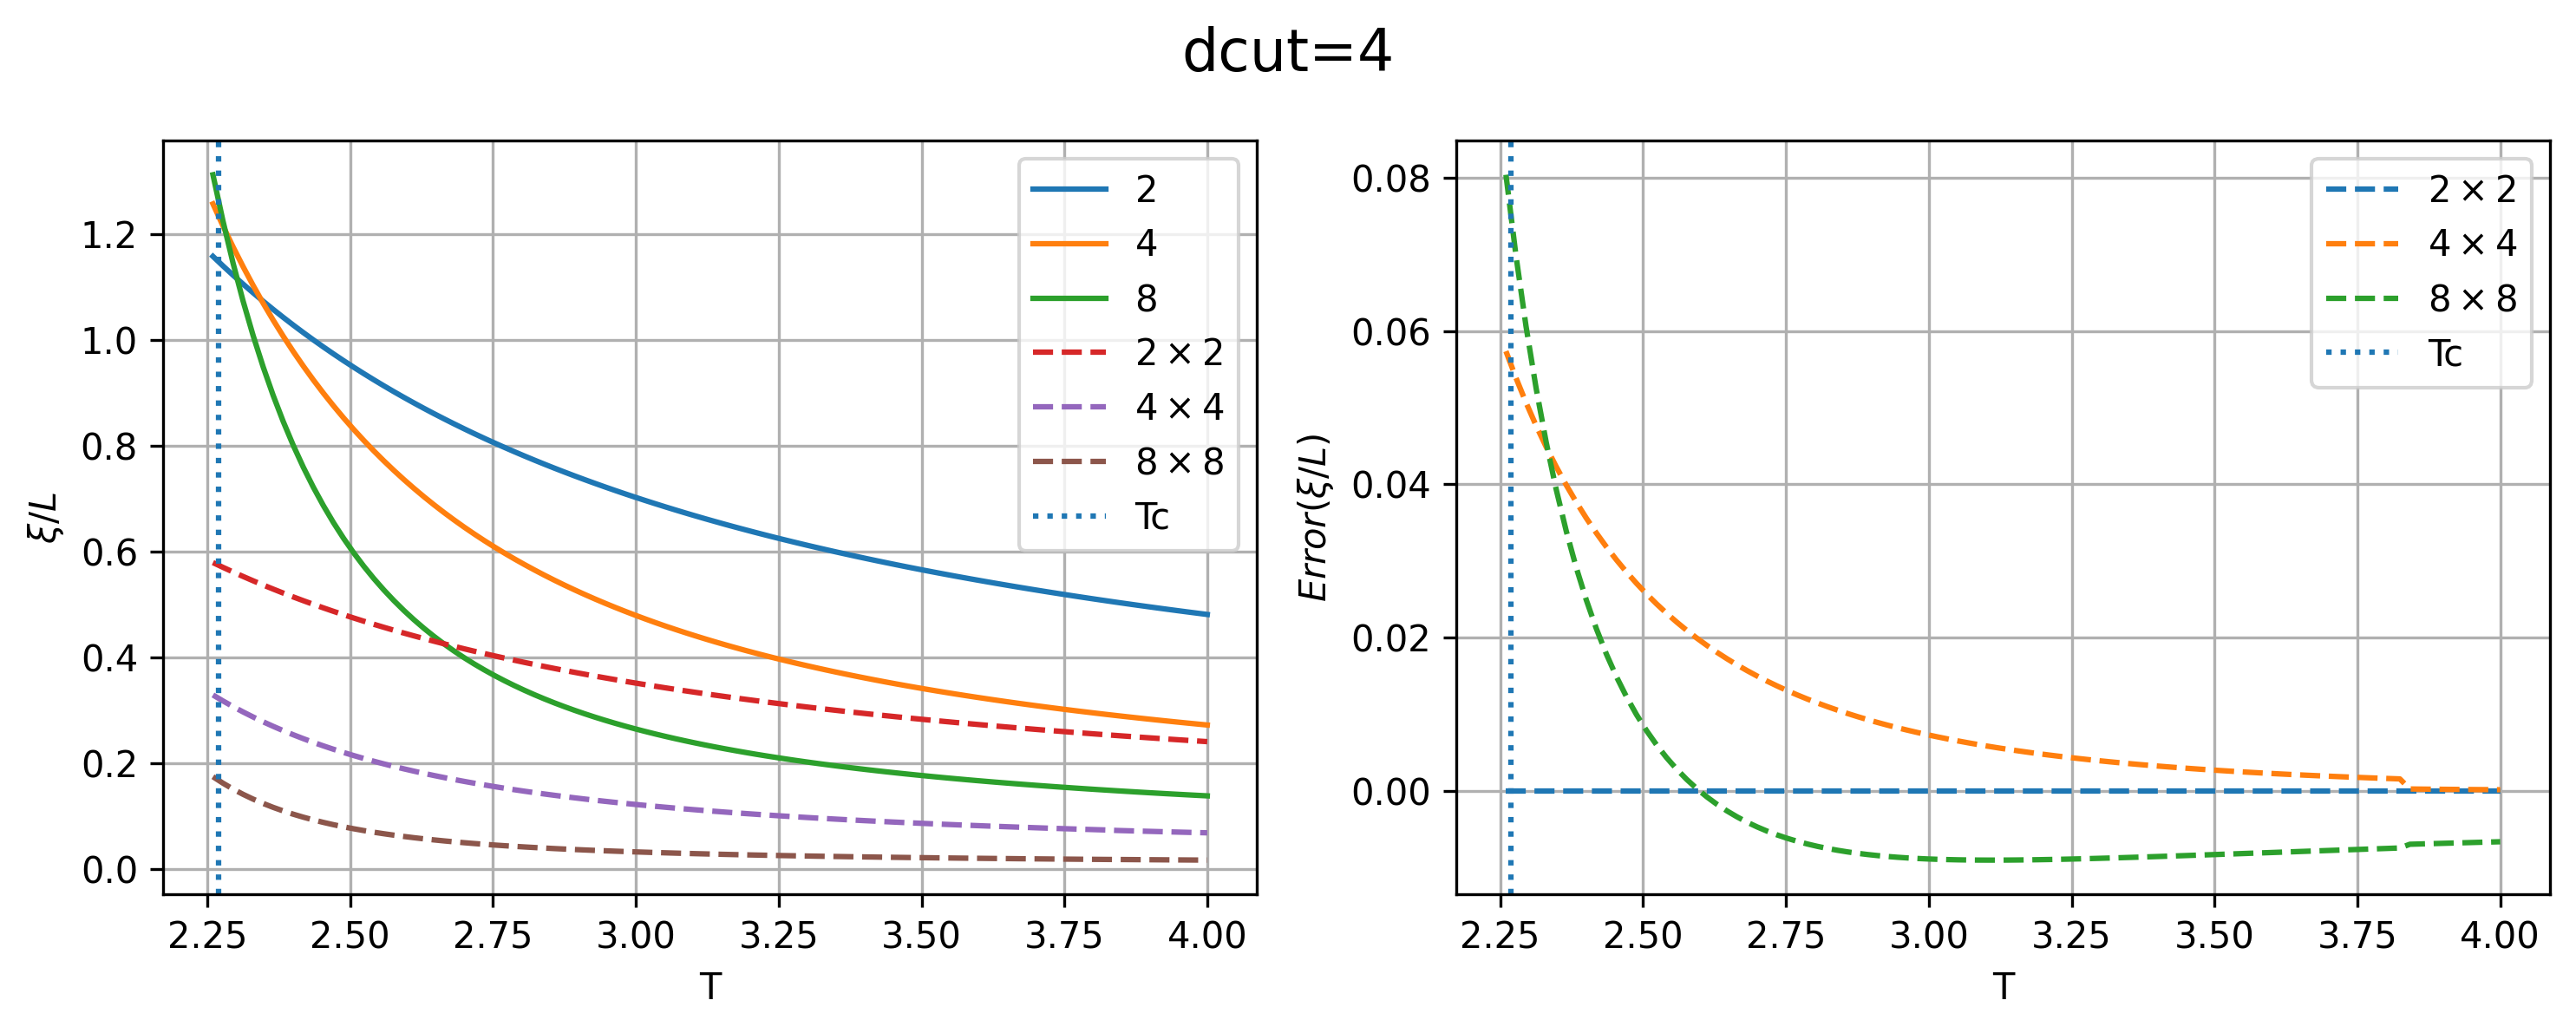

In [10]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_4[i]/2**(i-1),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_4[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
%%time
dcut = 10

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_10 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_10, Corr_len_10_cytnx)

CPU times: user 1.26 s, sys: 346 ms, total: 1.6 s
Wall time: 467 ms


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


True

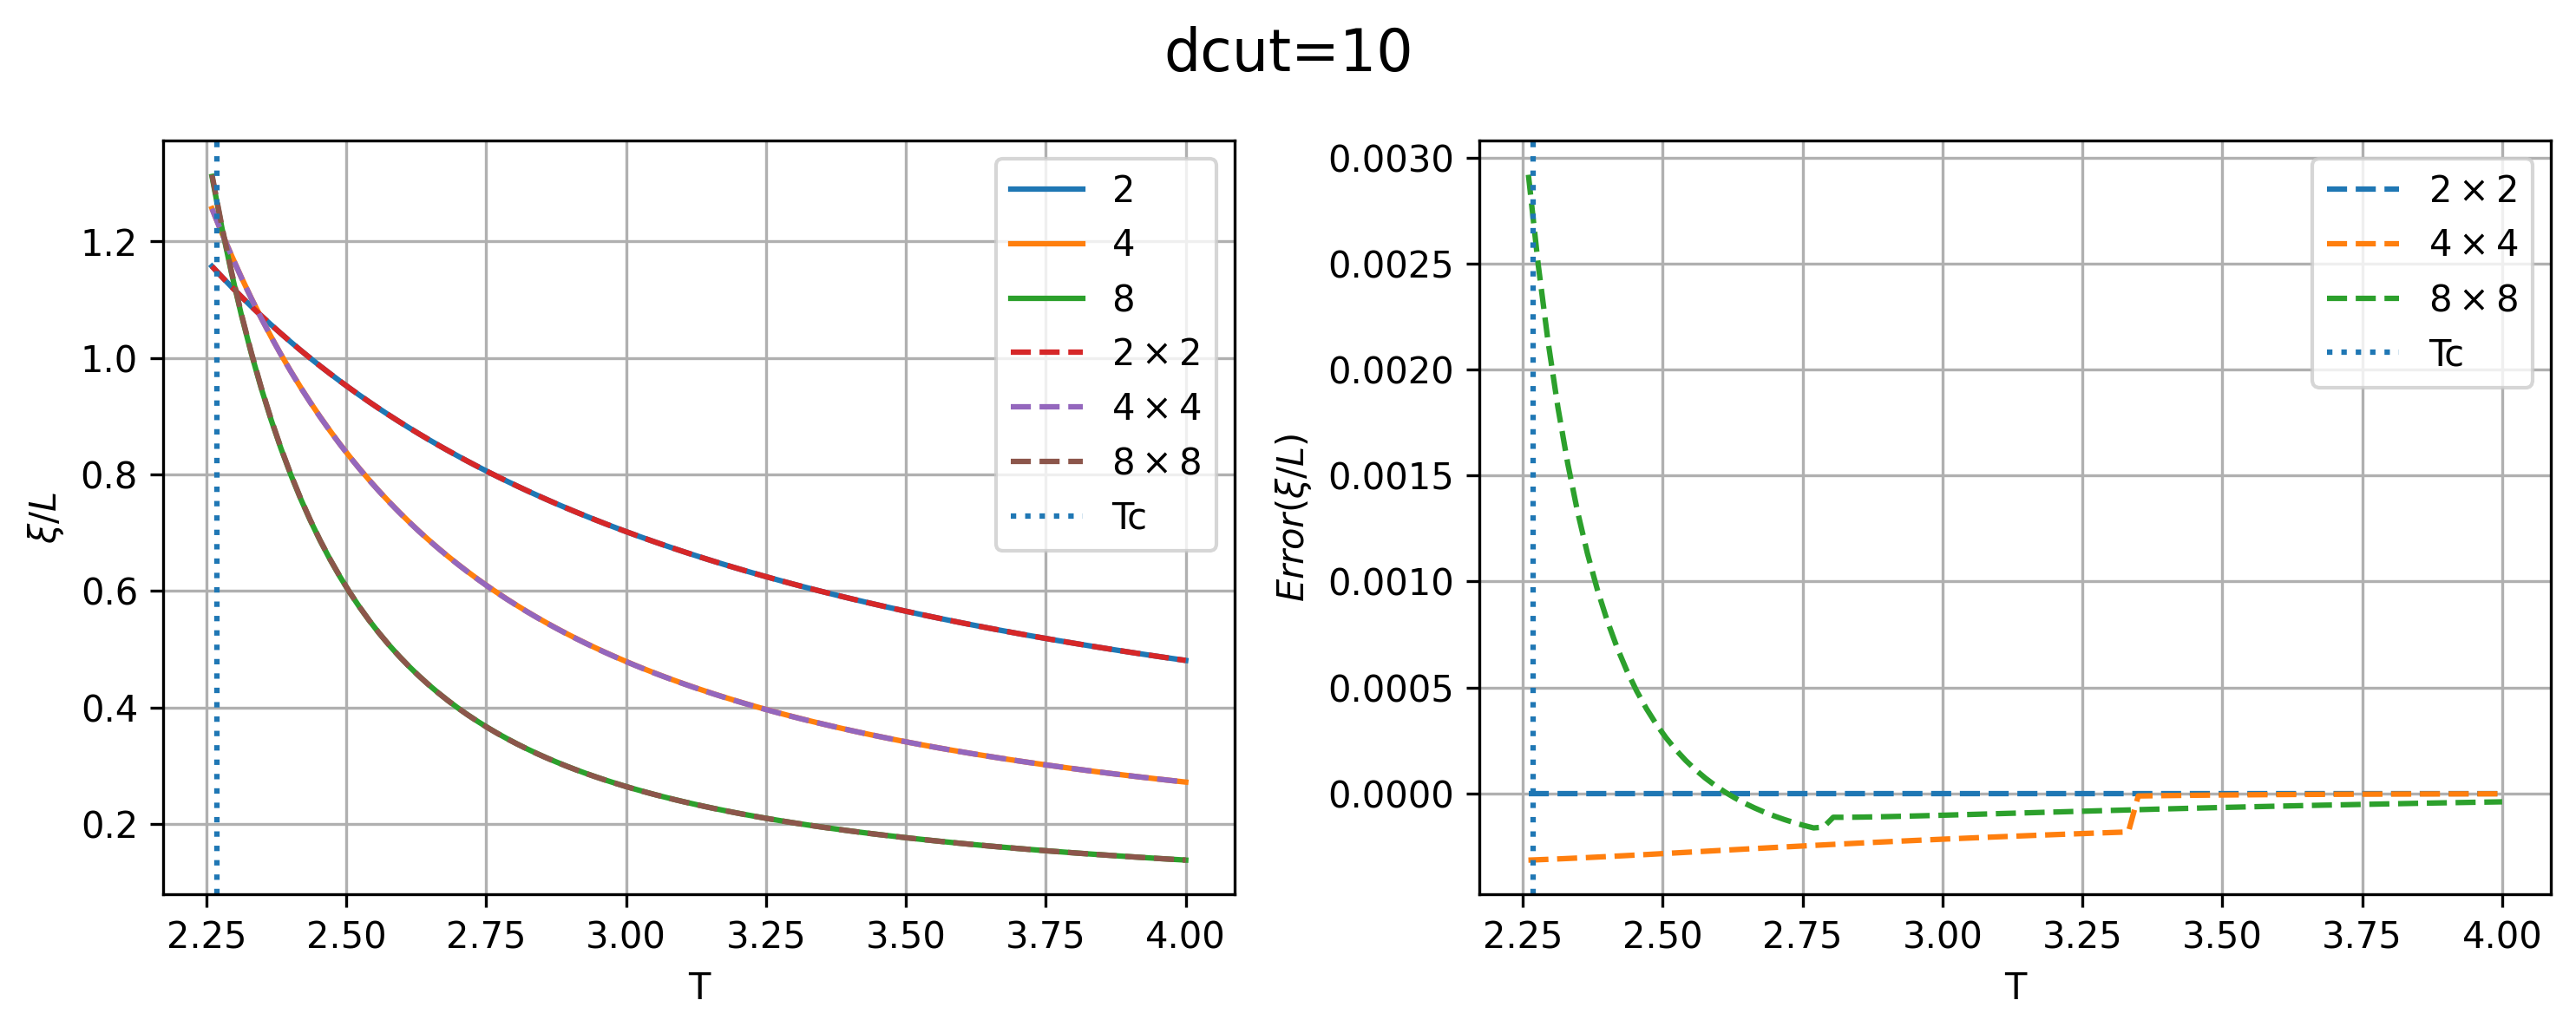

In [11]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_10[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_10[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
%%time
dcut = 20

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_20 = 1/(E[:,:,-2]-E[:,:,-1])
np.allclose(Corr_len_20, Corr_len_20_cytnx)

CPU times: user 19.1 s, sys: 8.43 s, total: 27.6 s
Wall time: 2.89 s


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


True

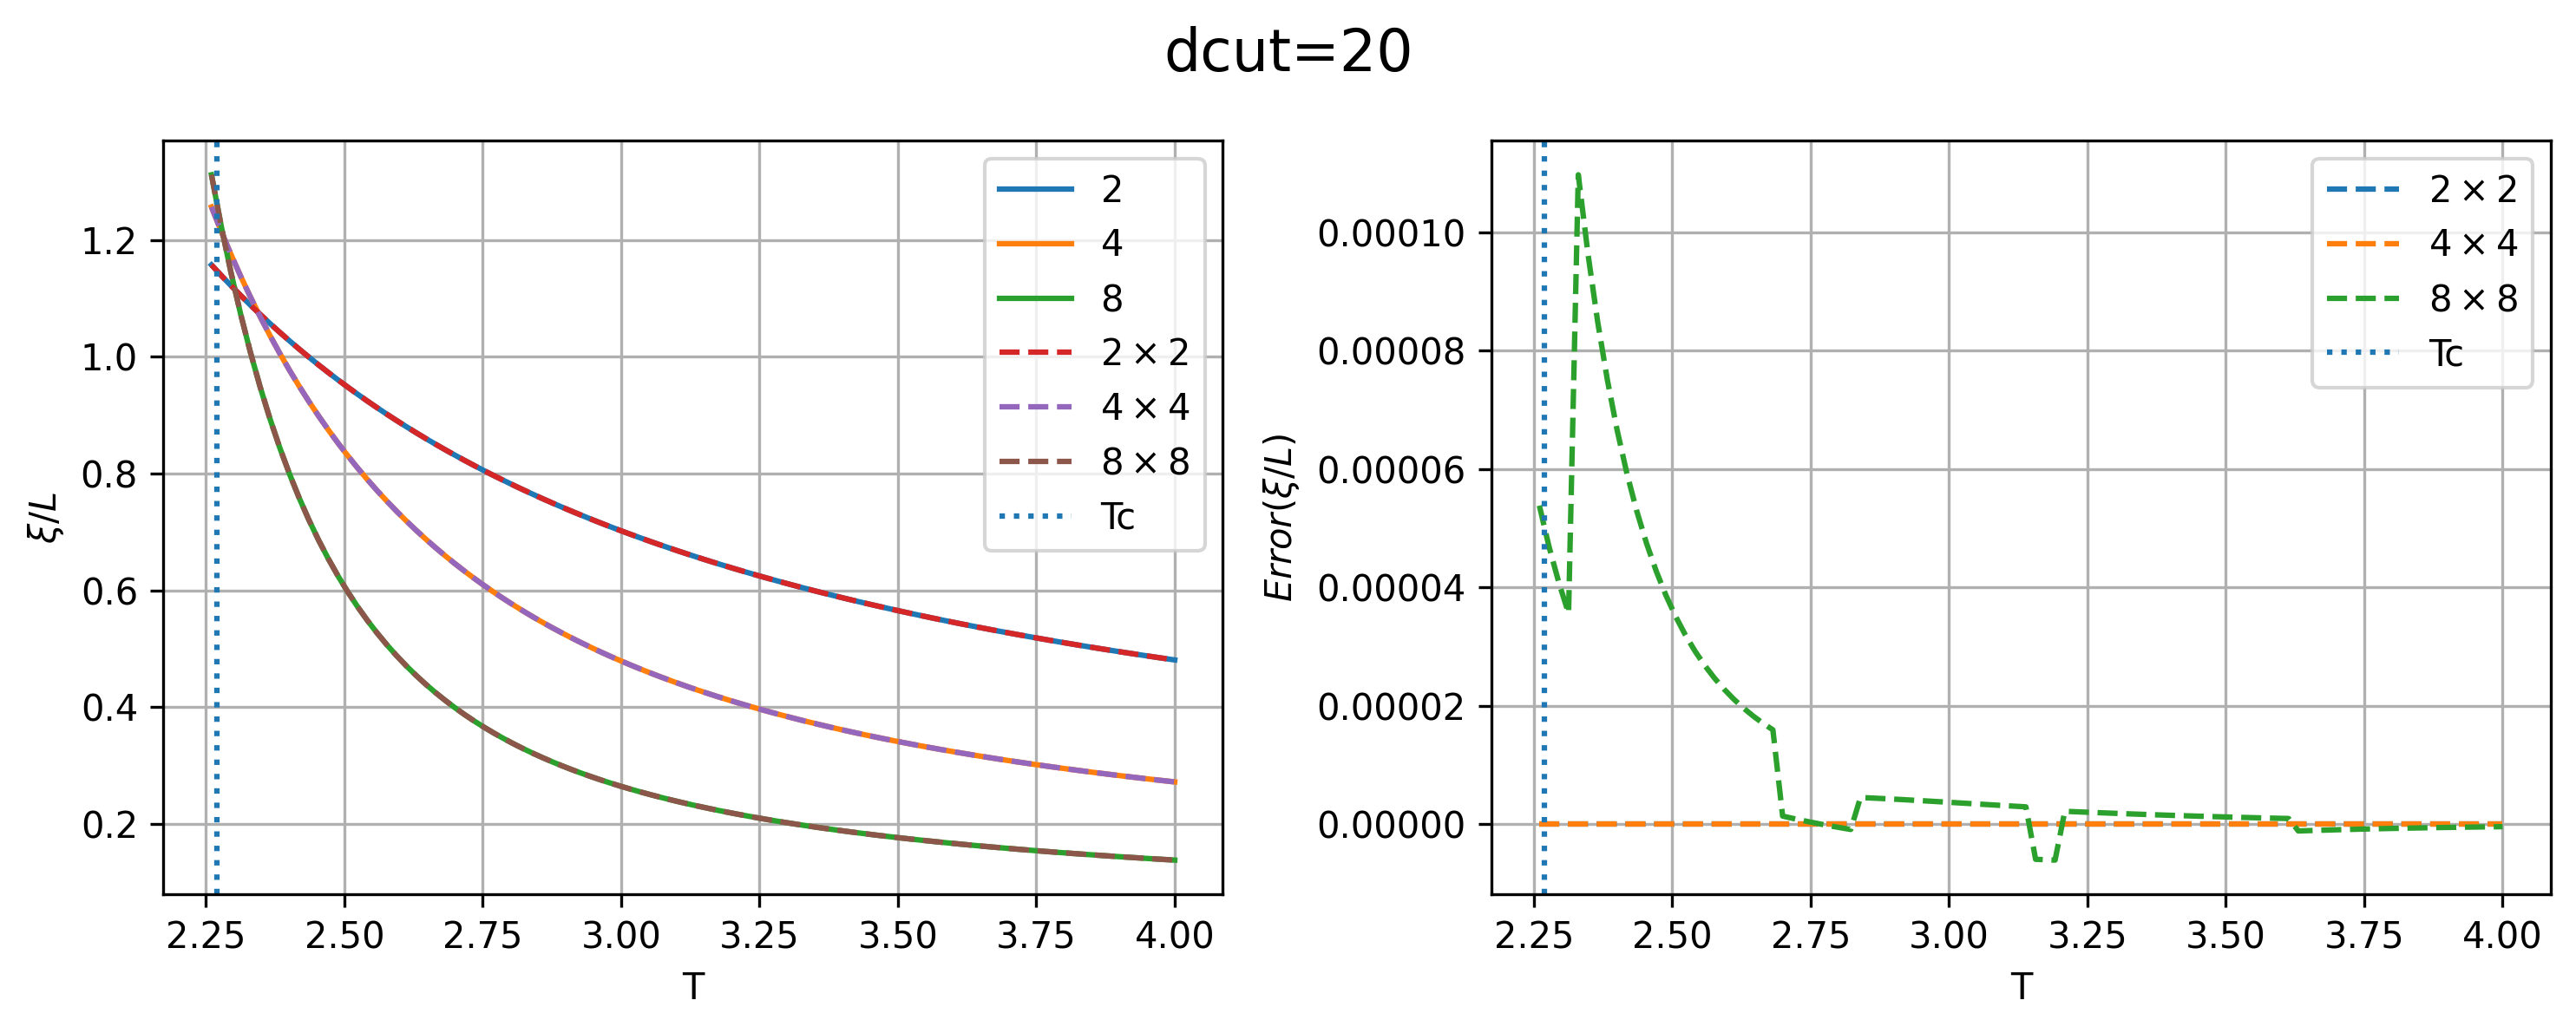

In [13]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_20[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
%%time
dcut = 40

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_40 = 1/(E[:,:,-2]-E[:,:,-1])

CPU times: user 6min 46s, sys: 1min 44s, total: 8min 31s
Wall time: 28.5 s


<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


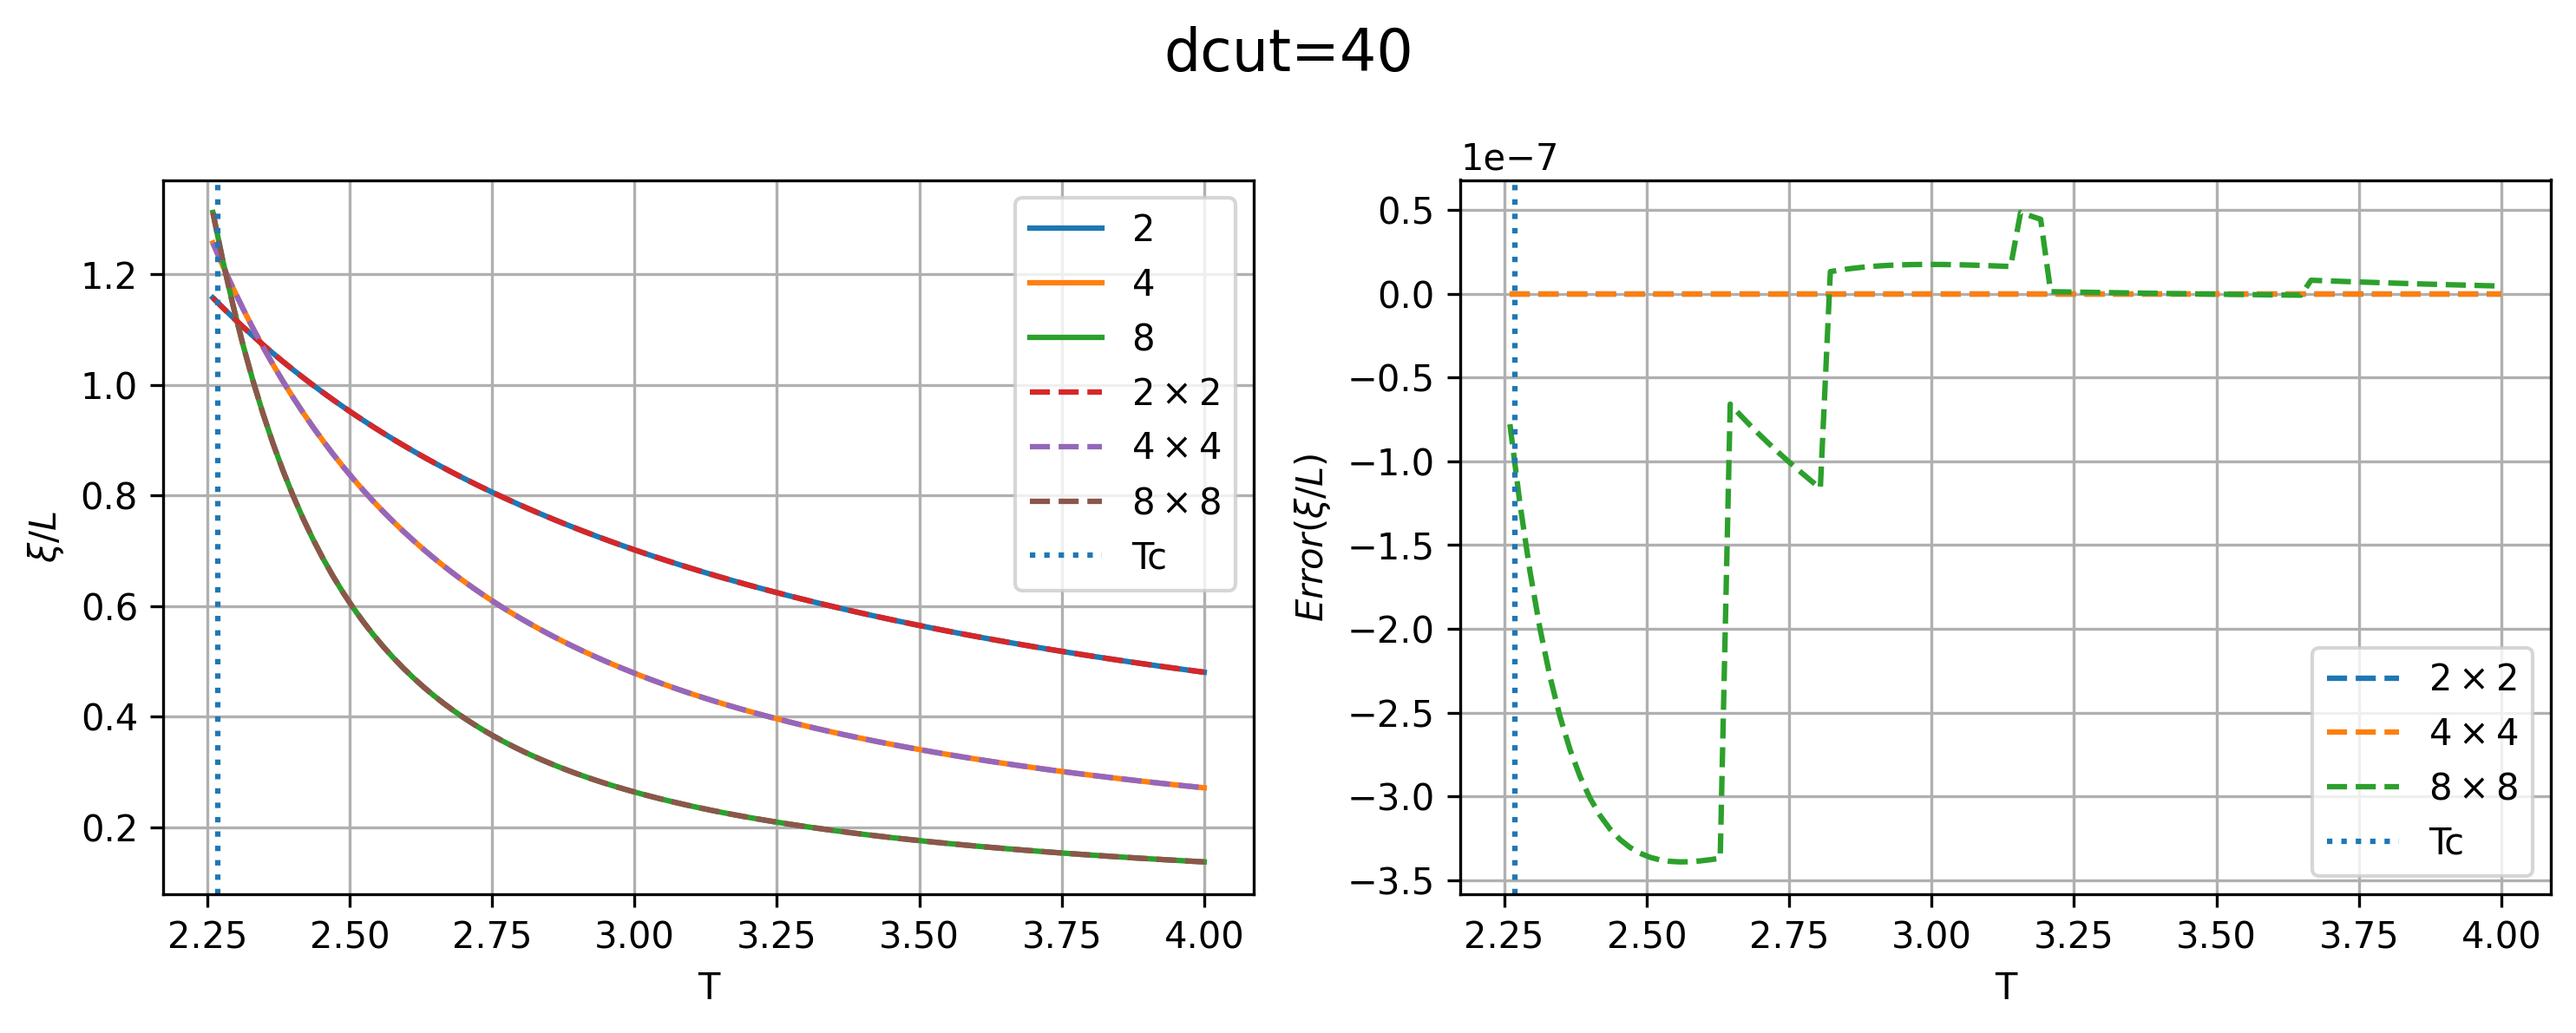

In [15]:
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_40[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_40[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


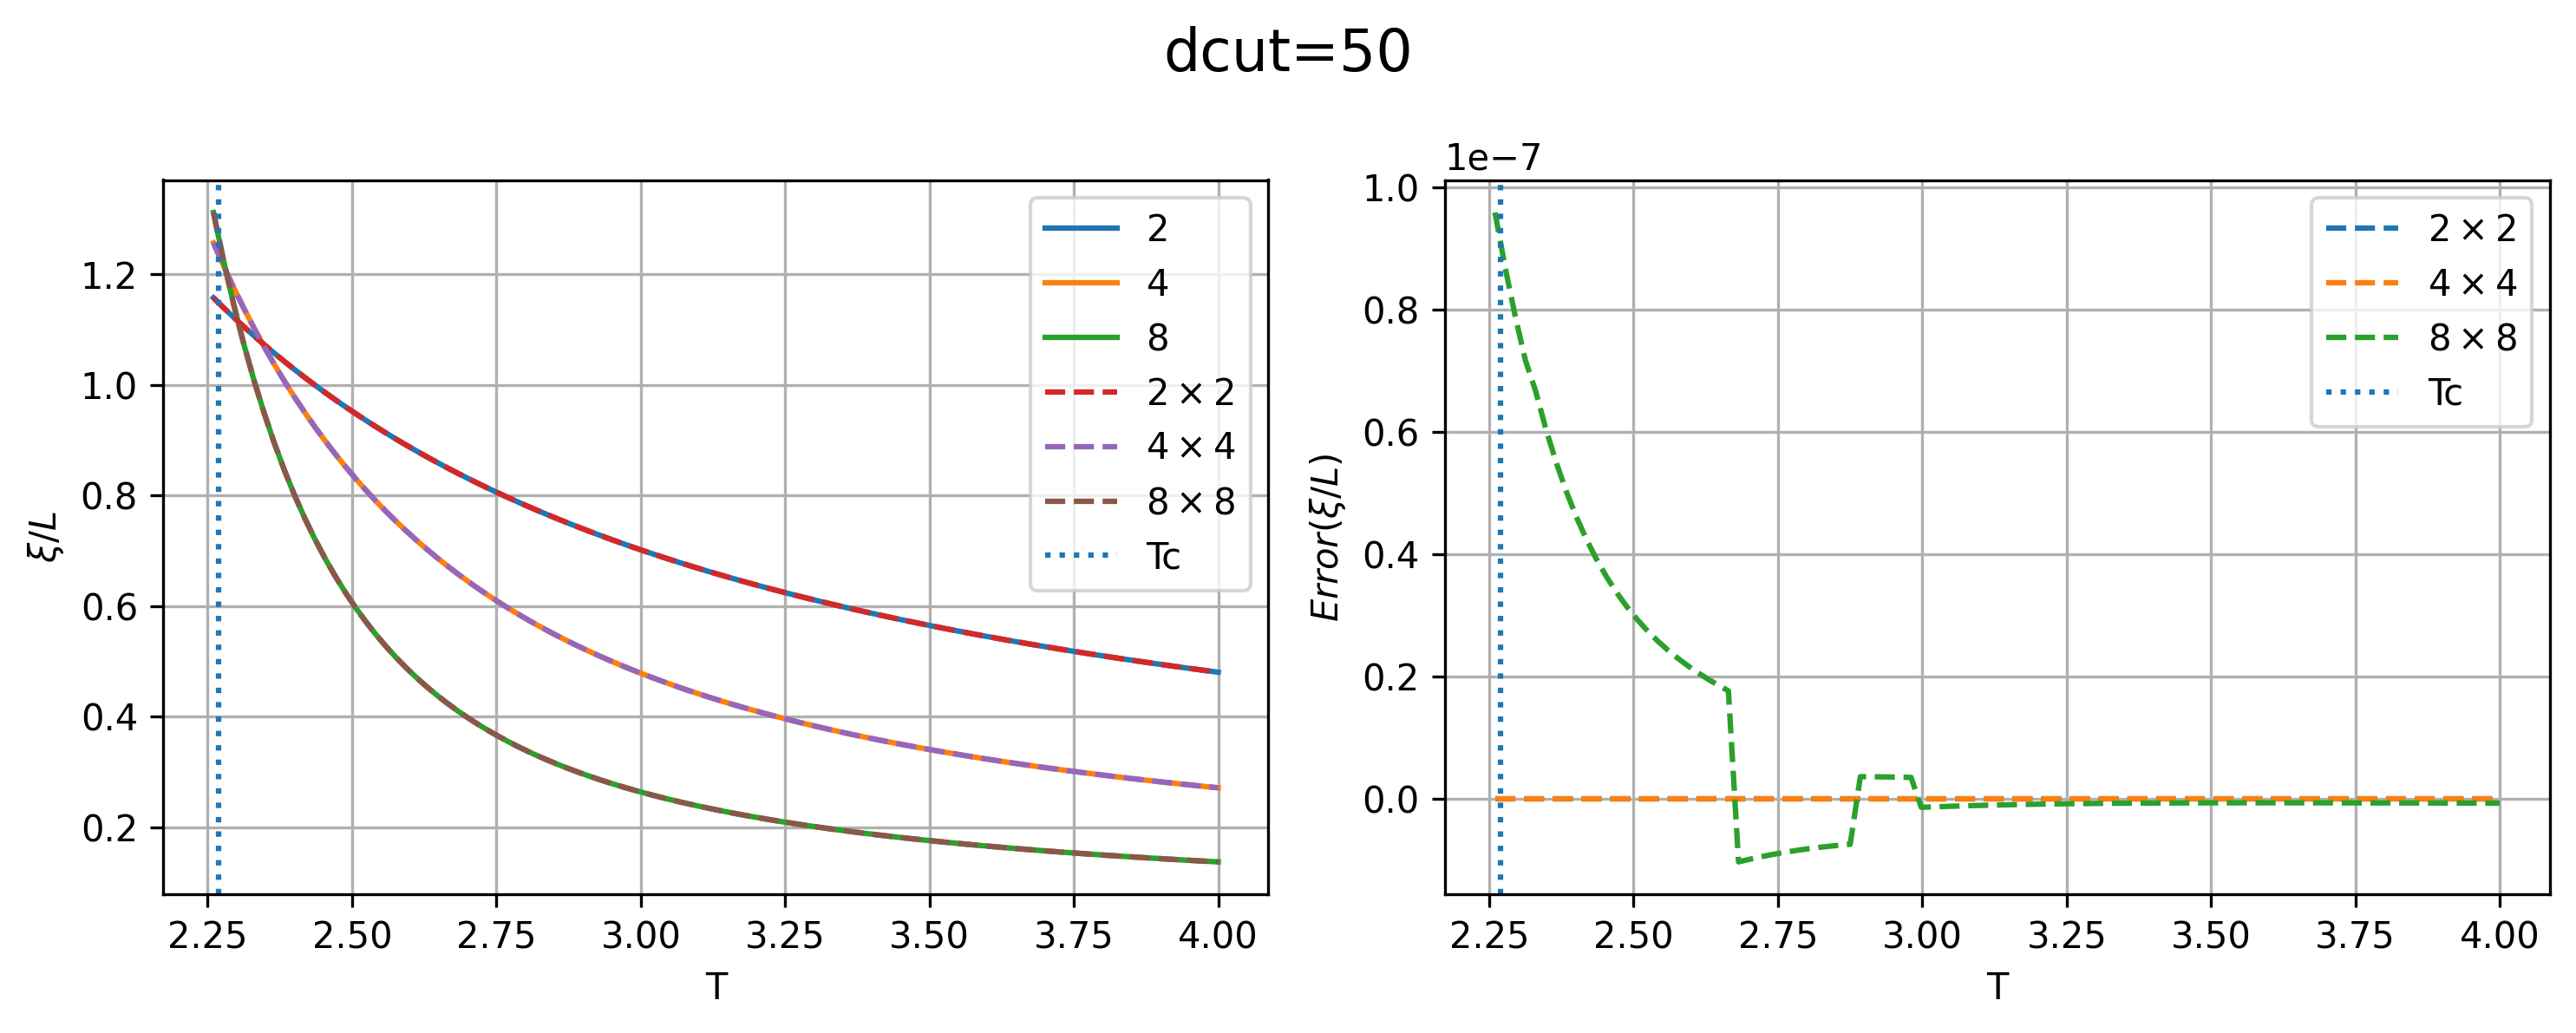

CPU times: user 11min 21s, sys: 2min 46s, total: 14min 7s
Wall time: 46.4 s


In [16]:
%%time
dcut = 50

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_50 = 1/(E[:,:,-2]-E[:,:,-1])
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_50[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_50[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


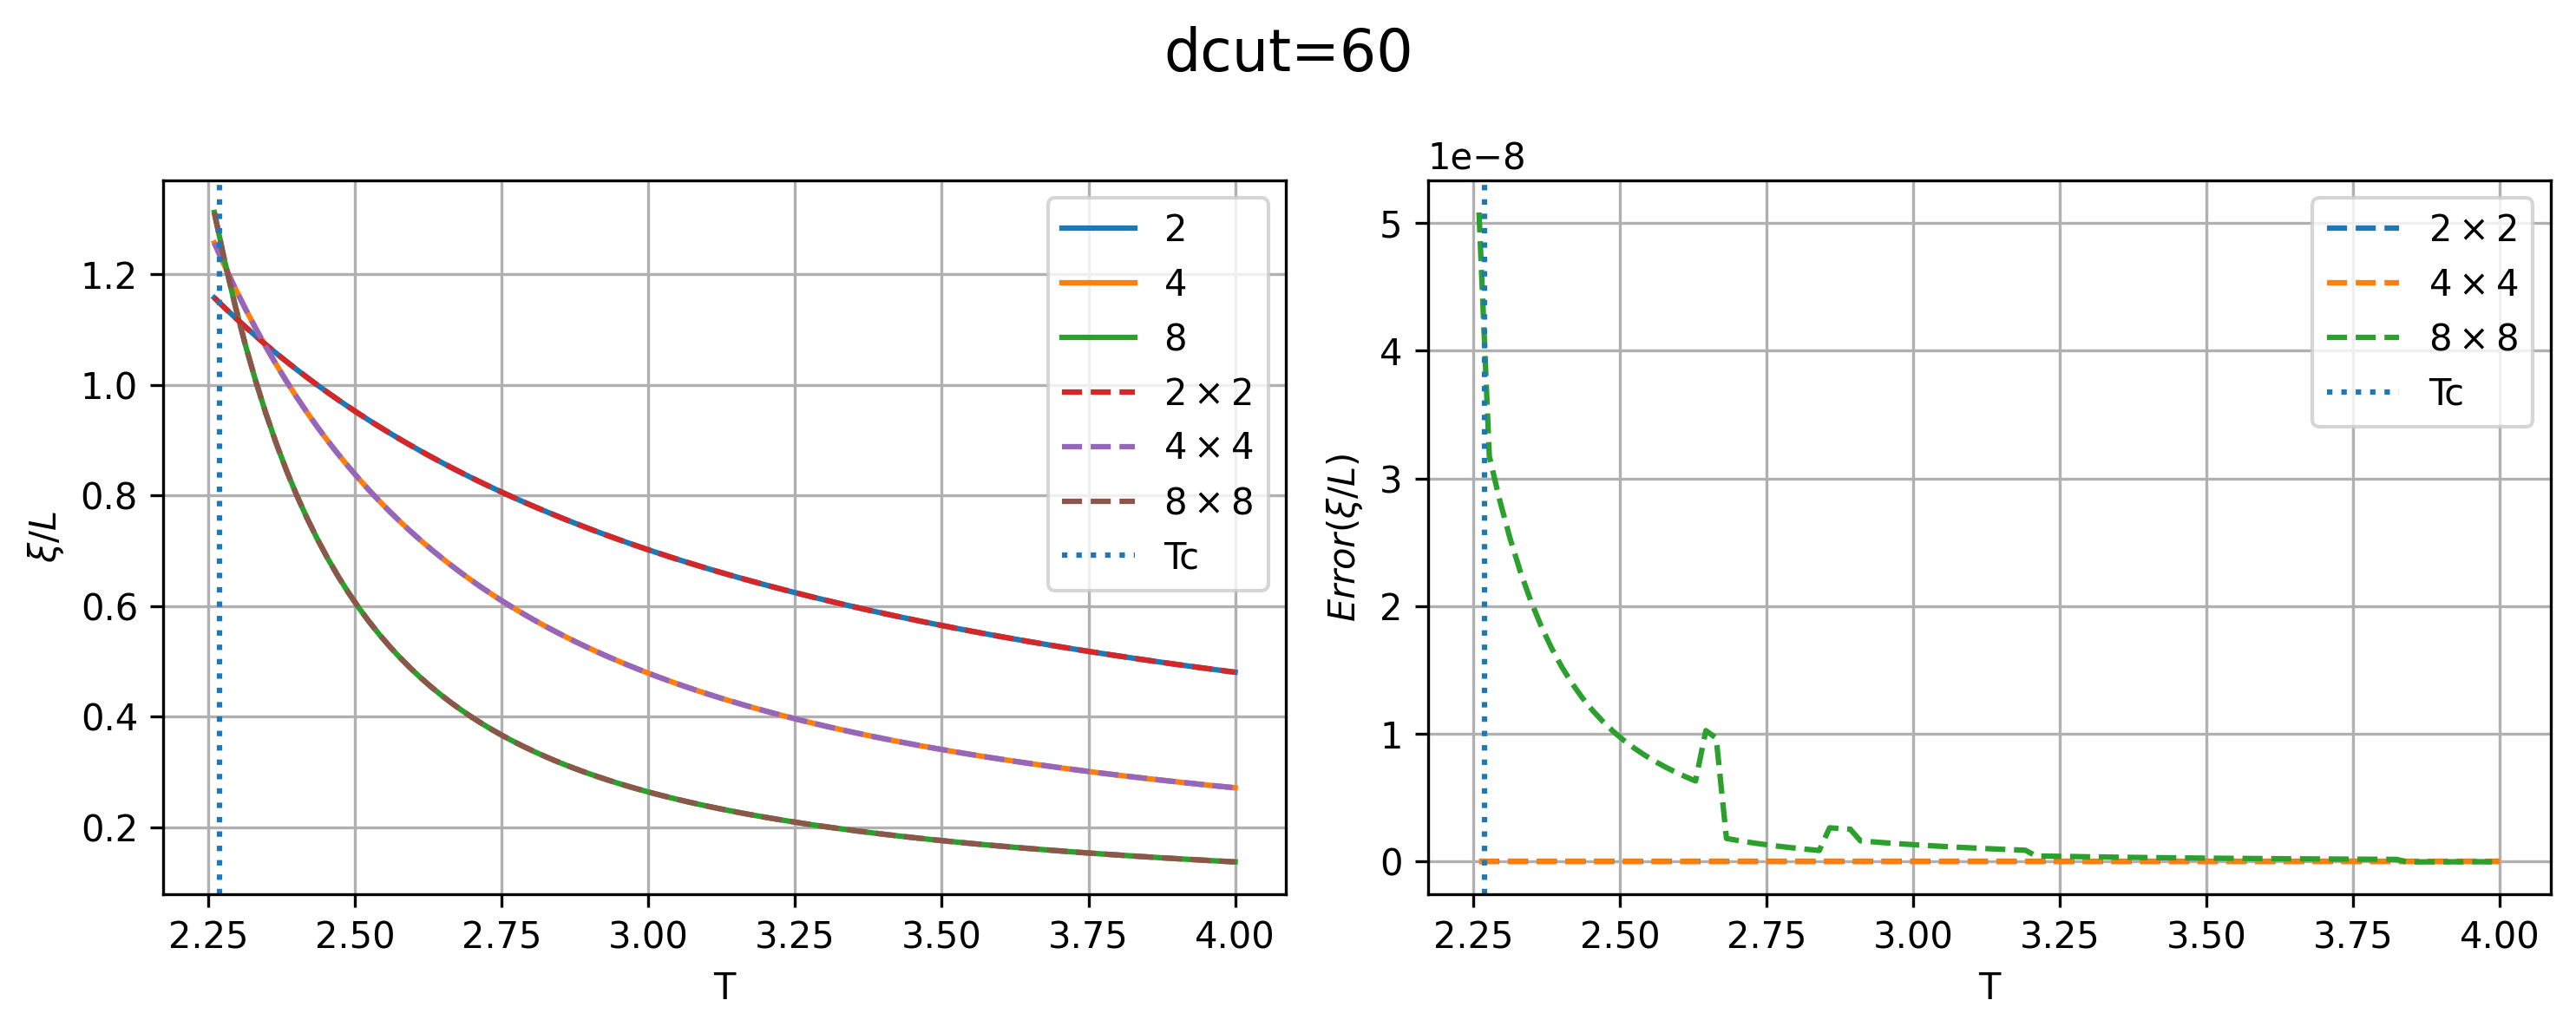

CPU times: user 17min 33s, sys: 4min 16s, total: 21min 49s
Wall time: 1min 11s


In [17]:
%%time
dcut = 60

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_60 = 1/(E[:,:,-2]-E[:,:,-1])
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_60[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_60[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


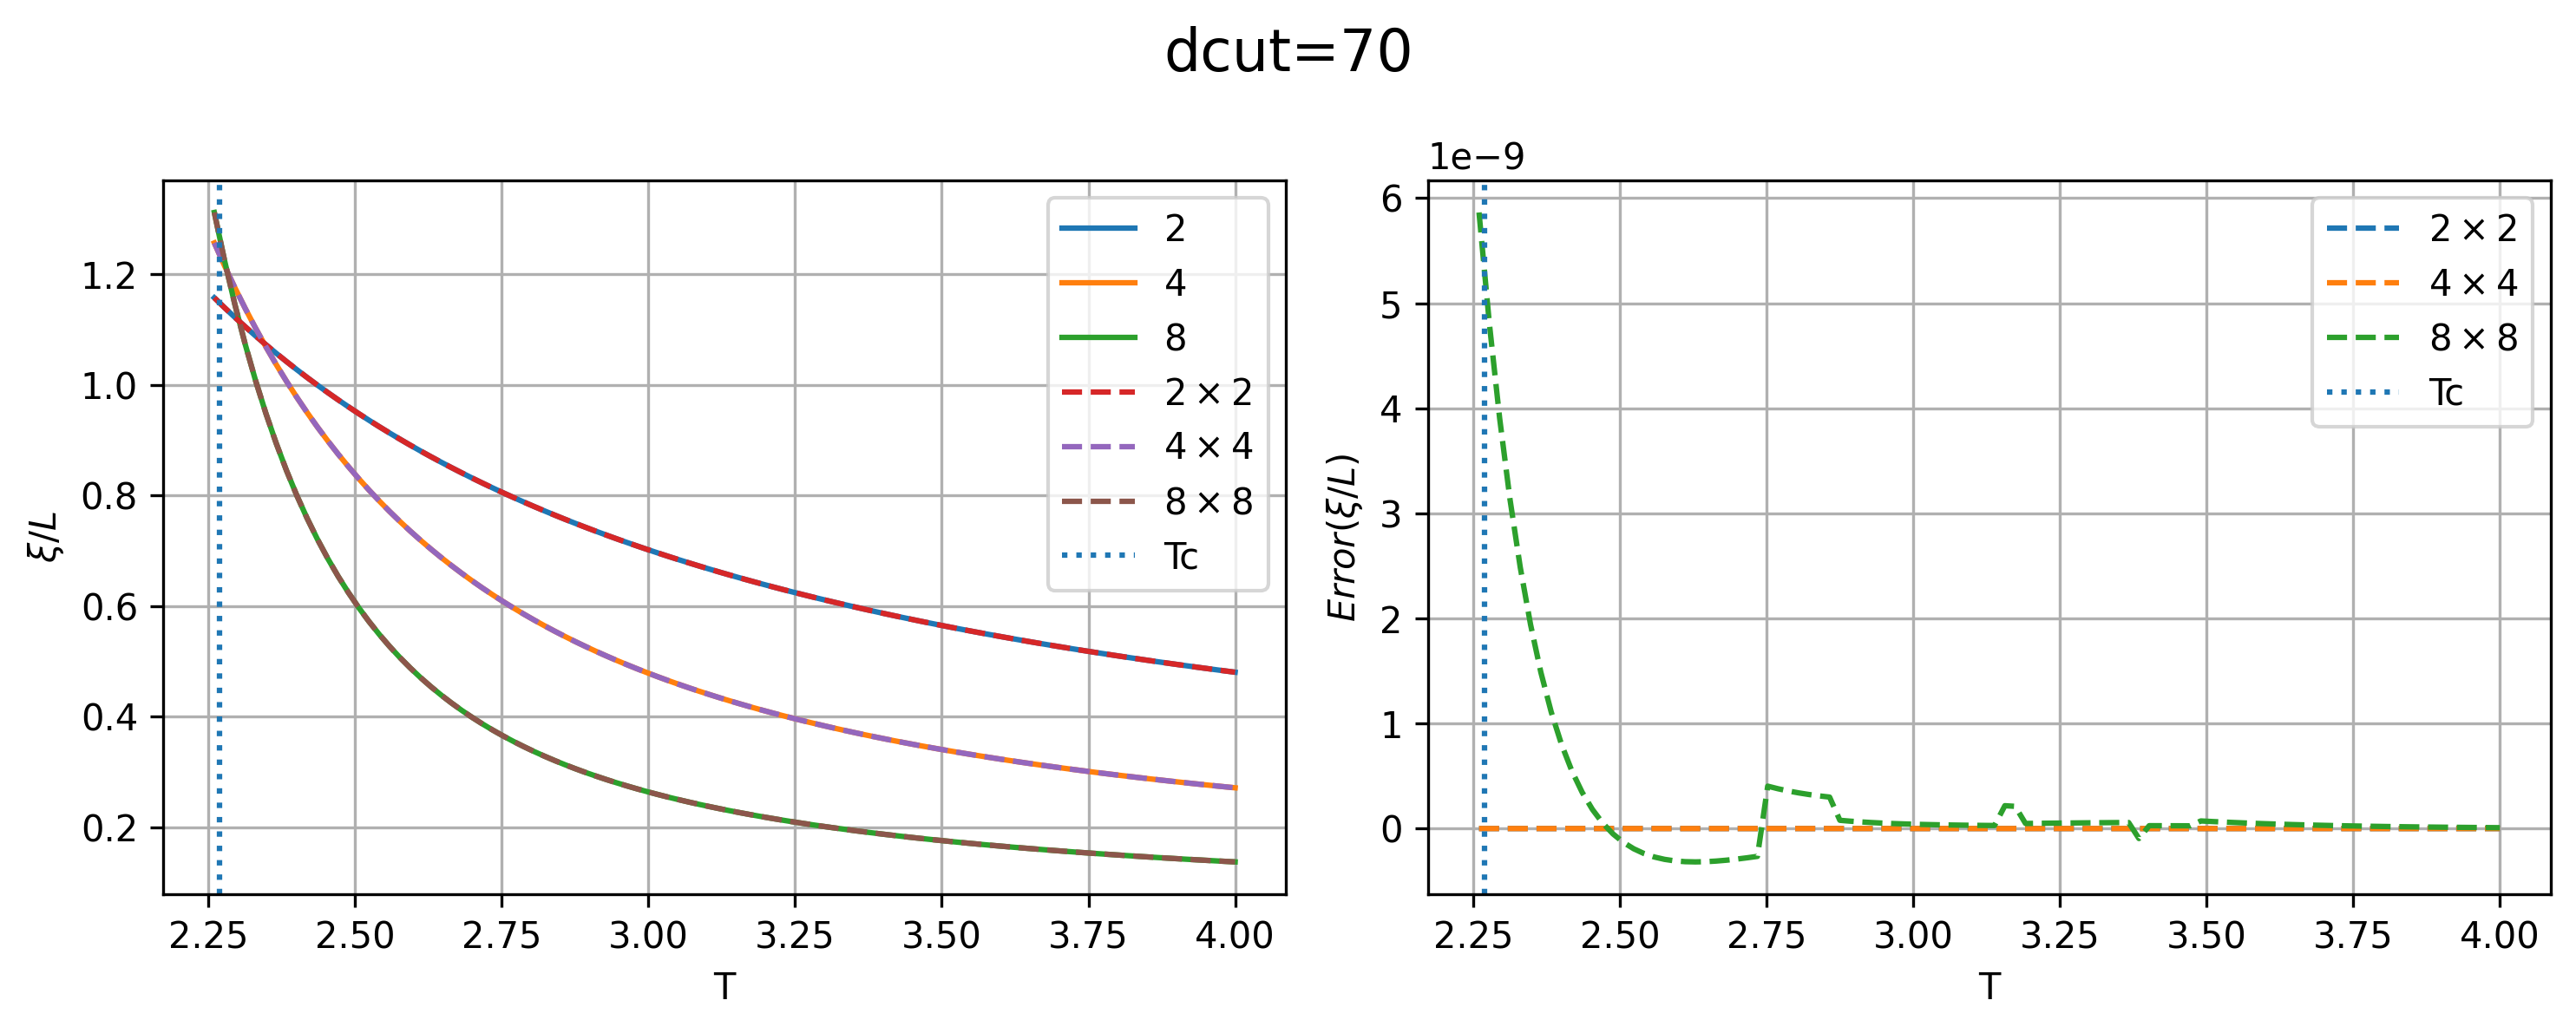

CPU times: user 24min 55s, sys: 5min 42s, total: 30min 37s
Wall time: 1min 37s


In [18]:
%%time
dcut = 70

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_70 = 1/(E[:,:,-2]-E[:,:,-1])
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_70[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_70[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

<timed exec>:14: RuntimeWarning: divide by zero encountered in divide


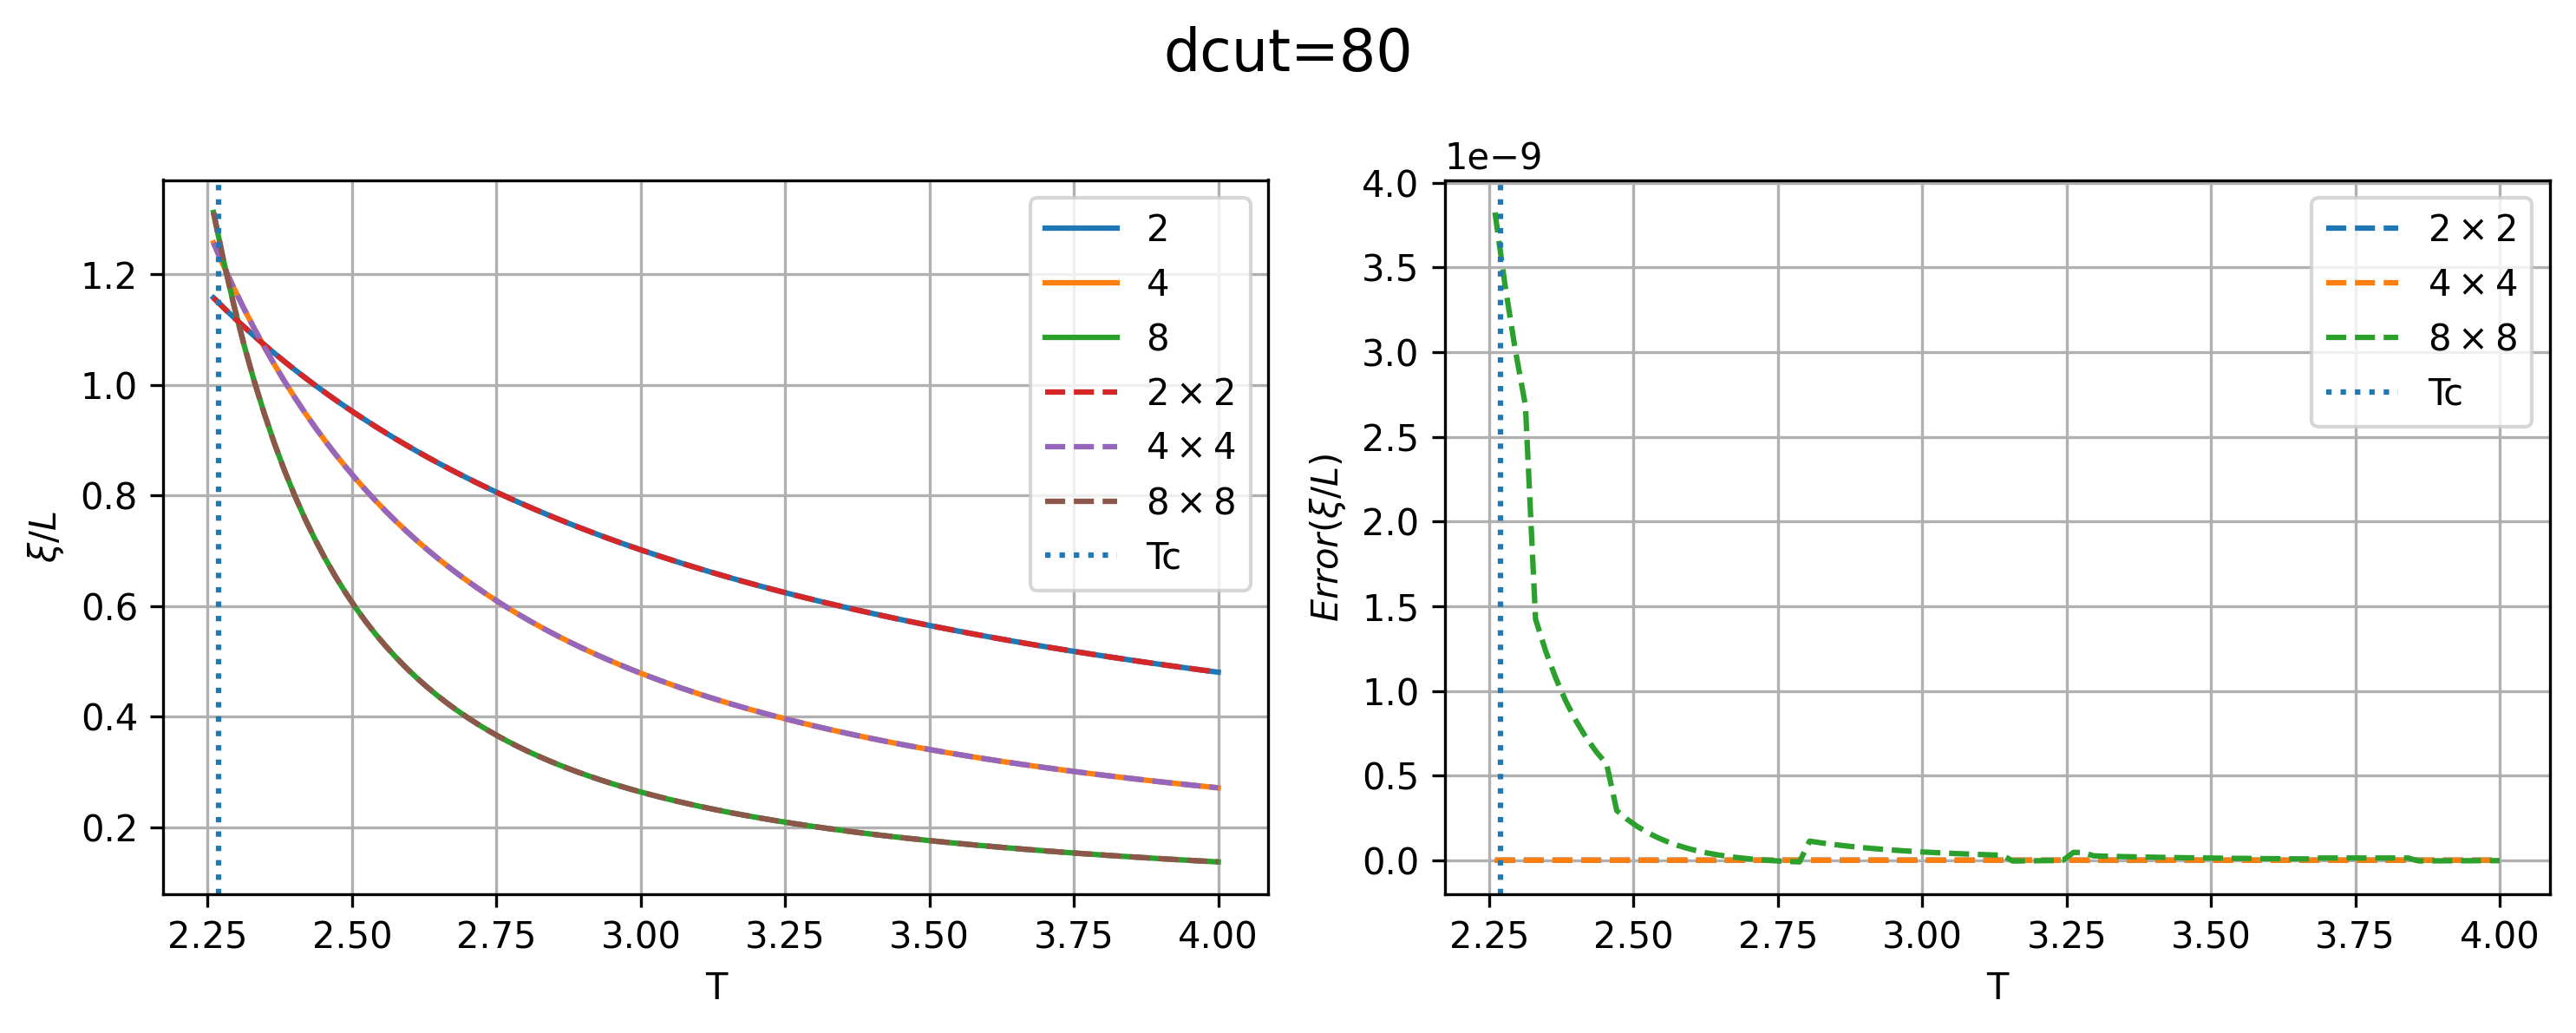

CPU times: user 35min, sys: 7min 24s, total: 42min 25s
Wall time: 2min 19s


In [19]:
%%time
dcut = 80

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
E = -np.log(W)
Corr_len_80 = 1/(E[:,:,-2]-E[:,:,-1])
plt.figure(figsize = (10,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
plt.subplot(1,2,1)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len[i]/2**(i-1),'-',label = f'${2**(i-1)}$')
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_80[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.grid()
plt.legend()
plt.subplot(1,2,2)
for i in range(2,MaxL+1):
    plt.plot(Temp, Corr_len_80[i] - (Corr_len[i]/2**(i-1)),'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$Error(\xi/L)$')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
MaxL = 11
Temp = np.linspace(2.265,2.285,100)
W = np.ones((MaxL+1,len(Temp),2))
E = np.ones((MaxL+1,len(Temp),2))
Tc = 2/np.log(1+np.sqrt(2))

In [ ]:
%%time
dcut = 30

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        del TL_Trace
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
    del TL
E = -np.log(W)
Corr_len_20 = 1/(E[:,:,-2]-E[:,:,-1])

plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((0,15))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

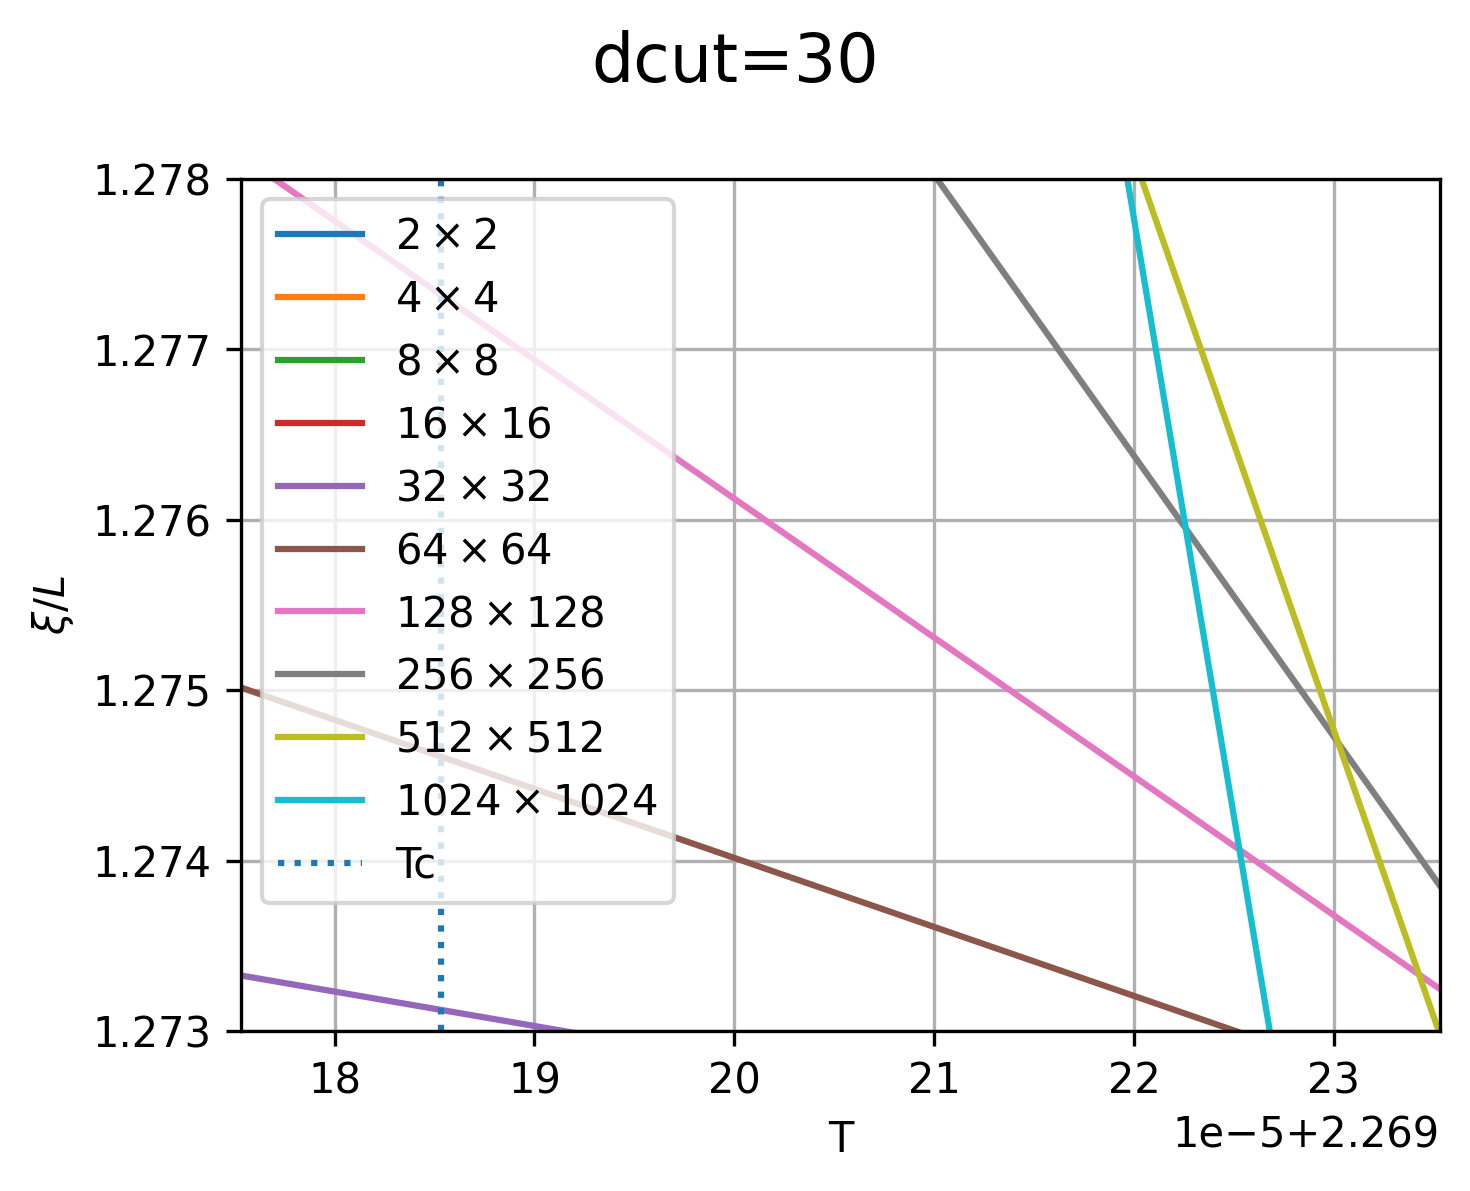

In [26]:
plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_20[i],'-',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((1.273,1.278))
plt.xlim((Tc-1e-5,Tc+5e-5))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
%%time
dcut = 40

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        del TL_Trace
        W[j,i,:] = eigvals[-2:]
        del eigvals, eigvecs
        TL = merge_y_truncate(TLx,TLx,dcut)
        del TLx
        TL = TL/torch.mean(torch.abs(TL))
    del TL
E = -np.log(W)
Corr_len_40 = 1/(E[:,:,-2]-E[:,:,-1])
plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_40[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((1.05,1.3))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
%%time
dcut = 60

for i,temp in enumerate(Temp):
    T_bare = get_T_bare(1/temp)
    TL = T_bare
    for j in range(2,MaxL+1):
        TLx = merge_x_truncate(TL,TL,dcut)
        TL_Trace = merge_y(TLx,TLx,True,True)
        eigvals, eigvecs = torch.linalg.eigh(TL_Trace)
        del TL_Trace
        W[j,i,:] = eigvals[-2:]
        TL = merge_y_truncate(TLx,TLx,dcut)
        TL = TL/torch.mean(torch.abs(TL))
    del TL
E = -np.log(W)
Corr_len_60 = 1/(E[:,:,-2]-E[:,:,-1])
plt.figure(figsize = (5,4),dpi = 300)
plt.suptitle(f'dcut={dcut}',fontsize = 16)
for i in range(2,MaxL+1):
    plt.plot(Temp,Corr_len_60[i],'--',label = f'${2**(i-1)}\\times{2**(i-1)}$')
plt.axvline(x=Tc,ls=':',label = 'Tc')
plt.xlabel('T')
plt.ylabel(r'$\xi/L$')
plt.ylim((1.05,1.3))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
for i in range(1,80):
    N = i + 1
    print(N)
    A = torch.randn(N,N,N,N, dtype = torch.float64)
    print(A.shape)
    A = A.reshape(N * N, N * N)
    print(A.shape)
    %time U, S, V = torch.svd(A)
    U = U[:,:N]
    S = S[:N]
    print(U.shape)
    %time U1, S1, V1 = torch.svd_lowrank(A, q=N, niter=100)
    print(U1.shape)
    print(torch.allclose(torch.abs(U1), torch.abs(U)))
    print(torch.max(torch.abs(U1)-torch.abs(U)))
    print(torch.allclose(U1 @ U1.T, U @ U.T))
    print(torch.max(U1 @ U1.T - U @ U.T))